In [30]:
import pandas as pd
df=pd.read_csv("./ml_classification_dataset.csv")
df.head()

,ID,Age,Salary,Experience_Years,Purchased
0,1,56.0,25287.0,17.0,0
1,2,46.0,54387.0,39.0,0
2,3,32.0,28512.0,20.0,0
3,4,60.0,NaN,14.0,1
4,5,25.0,83076.0,32.0,1


In [31]:

ddf=df.drop(df.columns[1],axis=1)
ddf.shape

(1000, 4)

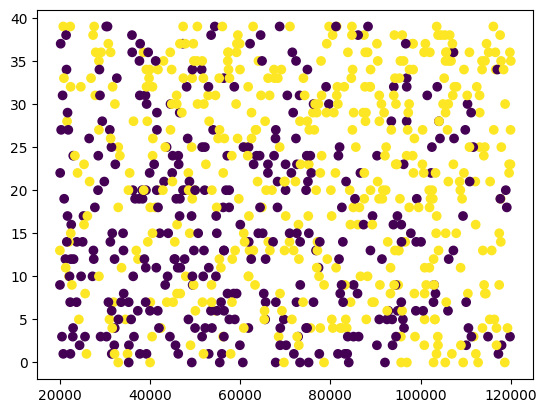

In [32]:
import matplotlib.pyplot as plt
plt.scatter(ddf["Salary"], ddf["Experience_Years"], c=ddf["Purchased"])
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline=Pipeline([("imputer", SimpleImputer(strategy="mean")), ("model", LogisticRegression())])

In [33]:
X=df.iloc[:,1:4]
y=df.iloc[:,-1]
print(X)
X.shape
y

      Age    Salary  Experience_Years
0    56.0   25287.0              17.0
1    46.0   54387.0              39.0
2    32.0   28512.0              20.0
3    60.0       NaN              14.0
4    25.0   83076.0              32.0
..    ...       ...               ...
995  22.0   37778.0               1.0
996  40.0   65241.0               8.0
997  27.0   62229.0               NaN
998  61.0  106652.0               NaN
999  19.0   68364.0              33.0

[1000 rows x 3 columns]


0      0
1      0
2      0
3      1
4      1
      ..
995    0
996    0
997    0
998    0
999    1
Name: Purchased, Length: 1000, dtype: int64

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.46      0.54       115
           1       0.63      0.79      0.70       135

    accuracy                           0.64       250
   macro avg       0.64      0.63      0.62       250
weighted avg       0.64      0.64      0.63       250

[[ 53  62]
 [ 28 107]]
